# L12 · Attention from Scratch: a Tiny Transformer Reads Motif Order

*Companion notebook for Lecture 12 — Attention and Transformers (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Implement scaled dot-product attention and multi-head attention in NumPy, checking every matrix shape, and redo the lecture's worked example.
2. See numerically why scores are divided by $\sqrt{d_k}$, and that self-attention is **permutation equivariant** until positional encodings are added.
3. Build a tiny Transformer encoder in PyTorch (convolutional embedding → 2 encoder blocks → mean pool) and check its attention layer against the NumPy version.
4. Train it and a pooled CNN on L11's CTCF/FOXA1 motif-order task, and explain why only the Transformer **with positions** solves it.
5. Read attention maps: find the heads that locate each motif.

Runtime: about 1–2 minutes on a laptop CPU (three models × 10 epochs, ~15–25 s each). No GPU needed.

In [1]:
import sys, pathlib, time, math, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from course_utils import (seed_everything, plot_style, PALETTE, BASES, load_jaspar, pwm_from_counts,
                          plot_logo, sample_from_pwm, random_dna)

plot_style()
torch.set_num_threads(4)            # small models: 4 threads is as fast as more
np.set_printoptions(precision=3, suppress=True)
COL_A, COL_B = PALETTE[0], PALETTE[5]   # CTCF blue, FOXA1 vermillion (same colours as L11)

# task and model settings (identical to the lecture file slides_src/lectures/L12_attention_transformers.py)
MOTIF_A, MOTIF_B = "MA0139.1", "MA0148.4"   # CTCF, FOXA1 (JASPAR)
MIN_GAP, CONV_W = 5, 19                     # >= 5 bp between the two sites; 19-bp convolutional embedding
SEQ_L, POOL, N_TRAIN, N_TEST, EPOCHS = 200, 4, 4000, 1000, 10

## 1. Dataset: a motif "grammar" in simulated DNA

**Biological question.** Transcription factors (TFs) bind short DNA words (*motifs*). Whether a regulatory region is active often depends not only on *which* motifs are present but on their **arrangement** — order, orientation, spacing — the so-called *regulatory grammar*. Enhancers can also act on promoters tens of kilobases away, so models of regulatory DNA must relate positions that are far apart. This notebook uses a controlled toy version of that problem where we know the true rule.

- **Motif A = CTCF** (JASPAR MA0139.1, 19 bp, GC-rich): the insulator protein that anchors chromatin loops.
- **Motif B = FOXA1** (JASPAR MA0148.4, 12 bp, AT-rich): a pioneer factor in liver, breast and prostate.
- **One sample** = a 200-bp random DNA sequence (50% GC) with **one** CTCF site and **one** FOXA1 site planted at random positions (anywhere, at least 5 bp apart, never overlapping), each site sampled from its position probability matrix.
- **Input:** one-hot sequence $\mathbf X \in \{0,1\}^{200\times 4}$. **Target:** $y = 1$ iff A (CTCF) is **upstream** of B (FOXA1).

This is L11's task 2 with one change: there is **no spacing window** (L11 required the sites to be 10–49 bp apart), so the two sites can be up to ~170 bp apart. Every sequence contains both motifs, so *detecting* motifs is useless on its own — only their order carries the label.

**Source.** Motif count matrices from JASPAR (Rauluseviciute et al., *Nucleic Acids Research* 52, D174–D182, 2024; JASPAR data are freely available under CC BY 4.0), downloaded once into `applications/data/`. The sequences themselves are simulated, so there are no privacy or licensing issues.

In [2]:
nameA, cA = load_jaspar(MOTIF_A)
nameB, cB = load_jaspar(MOTIF_B)
thA, thB = pwm_from_counts(cA), pwm_from_counts(cB)
WA, WB = len(thA), len(thB)
print(f"motif A: {nameA} ({MOTIF_A}), width {WA};  motif B: {nameB} ({MOTIF_B}), width {WB}")


def make_grammar(n, rng, gap=None):
    """One CTCF (A) and one FOXA1 (B) site per sequence; y = 1 iff A is upstream of B.
    gap=None (default, as in the lecture): sites anywhere, >= MIN_GAP bp apart, no overlap.
    gap=(lo, hi): L11's spacing rule — the bp between the end of the first site and the start of the
    second must lie in [lo, hi) for both classes (so negatives are the same pair in the other order)."""
    seqs = random_dna(rng, n, SEQ_L)
    y = rng.integers(0, 2, n)
    pos = np.zeros((n, 2), int)
    out = []
    for i, s in enumerate(seqs):
        s = list(s)
        while True:
            pa, pb = int(rng.integers(0, SEQ_L - WA + 1)), int(rng.integers(0, SEQ_L - WB + 1))
            g = pb - (pa + WA) if y[i] else pa - (pb + WB)      # bp between first site's end and second's start
            ok = g >= MIN_GAP if gap is None else gap[0] <= g < gap[1]
            if ok:
                break
        s[pa:pa + WA] = sample_from_pwm(thA, rng, 1)[0]
        s[pb:pb + WB] = sample_from_pwm(thB, rng, 1)[0]
        out.append("".join(s))
        pos[i] = pa, pb
    return out, y, pos


rng = seed_everything(0)                       # same seed and call order as the lecture
S_tr, y_tr, pos_tr = make_grammar(N_TRAIN, rng)
S_te, y_te, pos_te = make_grammar(N_TEST, rng)
print(f"train {len(S_tr)} sequences, test {len(S_te)}; fraction y = 1: train {y_tr.mean():.3f}, test {y_te.mean():.3f}")
print("first test sequence (y = %d, A at %d, B at %d):" % (y_te[0], *pos_te[0]))
print(S_te[0])

motif A: CTCF (MA0139.1), width 19;  motif B: FOXA1 (MA0148.4), width 12


train 4000 sequences, test 1000; fraction y = 1: train 0.501, test 0.529
first test sequence (y = 1, A at 25, B at 152):
TTGTCAAGTAATAACTGTTTCGAAAATGCCACTAGGTGGCGTTCGCAGGTGGCAGACGATGTGTGACGGTCCCATTGGTTGCGTATGAGTATGTGATCACTCTAGGCCGCTCGCACTGCGTTCCCAGTAGAGACACTACTGAGCTGGGACGGGAGTAAACACTTCGATCCAACTTTGAGGTCCCGCGAGCCTCCTGGATC


## 2. Exploration: the two motifs and where they land

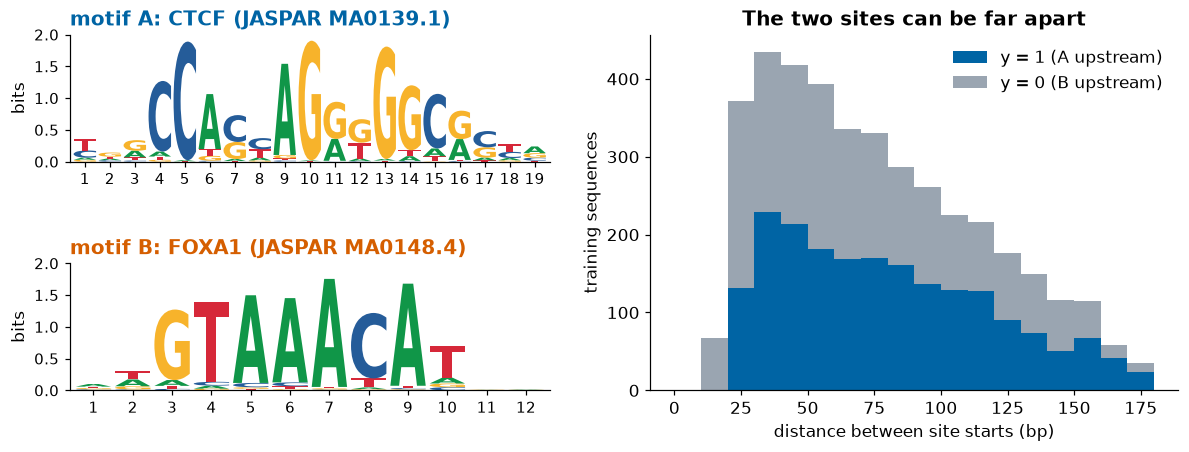

distance between site starts: median 69 bp, max 188 bp; 68% of pairs are >= 50 bp apart


In [3]:
fig = plt.figure(figsize=(13, 4.2))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.1], hspace=0.8, wspace=0.2)
for r, (th, nm, mid, col) in enumerate([(thA, nameA, MOTIF_A, COL_A), (thB, nameB, MOTIF_B, COL_B)]):
    ax = fig.add_subplot(gs[r, 0])
    plot_logo(ax, th)
    ax.set_title(f"motif {'AB'[r]}: {nm} (JASPAR {mid})", color=col, loc="left", fontsize=13)
    ax.tick_params(labelsize=10)
ax = fig.add_subplot(gs[:, 1])
sep_tr = np.abs(pos_tr[:, 0] - pos_tr[:, 1])
ax.hist([sep_tr[y_tr == 1], sep_tr[y_tr == 0]], bins=np.arange(0, 190, 10), stacked=True,
        color=[COL_A, "#9AA5B1"], label=["y = 1 (A upstream)", "y = 0 (B upstream)"])
ax.set(xlabel="distance between site starts (bp)", ylabel="training sequences",
       title="The two sites can be far apart")
ax.legend()
plt.show()
print(f"distance between site starts: median {np.median(sep_tr):.0f} bp, max {sep_tr.max()} bp; "
      f"{(sep_tr >= 50).mean():.0%} of pairs are >= 50 bp apart")

CTCF and FOXA1 look very different (GC-rich vs AT-rich), so finding them is easy. The hard part is that half of the pairs are more than ~60 bp apart — beyond the reach of one 19-bp filter.

## 3. Preprocessing: one-hot encoding
Rows are positions and columns the bases A, C, G, T (NOTATION_GUIDE); PyTorch convolutions want channels first, so the tensors are $n \times 4 \times 200$.

In [4]:
def onehot(seqs):
    idx = np.array([[BASES.index(c) for c in s] for s in seqs])
    return np.eye(4, dtype=np.float32)[idx]


X_tr = torch.tensor(onehot(S_tr)).transpose(1, 2)
X_te = torch.tensor(onehot(S_te)).transpose(1, 2)
yt_tr, yt_te = torch.tensor(y_tr).float(), torch.tensor(y_te).float()
print("X_tr", tuple(X_tr.shape), " X_te", tuple(X_te.shape))

X_tr (4000, 4, 200)  X_te (1000, 4, 200)


## 4. Model, part 1: attention from scratch in NumPy

### 4.1 Scaled dot-product attention
$$\mathrm{Attention}(\mathbf Q,\mathbf K,\mathbf V) = \mathrm{softmax}\Big(\frac{\mathbf Q\mathbf K^\top}{\sqrt{d_k}}\Big)\mathbf V,\qquad
\mathbf Q\in\mathbb R^{L\times d_k},\ \mathbf K\in\mathbb R^{L\times d_k},\ \mathbf V\in\mathbb R^{L\times d_v}.$$
The softmax runs over the **key** index $s$, separately for every query row $t$. An optional mask $\mathbf M$ (0 or $-\infty$) is added to the scores before the softmax (used for causal decoders).

In [5]:
def softmax_rows(Z):
    Z = Z - Z.max(-1, keepdims=True)          # stability trick: does not change the result
    E = np.exp(Z)
    return E / E.sum(-1, keepdims=True)


def attention(Q, K, V, M=None):
    """Scaled dot-product attention. Returns (output L x d_v, weights A L x L)."""
    L, dk = Q.shape
    assert K.shape == (L, dk), f"K must be {L} x {dk}, got {K.shape}"
    assert V.shape[0] == L, "one value per key"
    E = Q @ K.T / np.sqrt(dk)                 # scores e_ts, L x L
    if M is not None:
        E = E + M
    A = softmax_rows(E)                       # alpha_ts, each row sums to 1
    O = A @ V                                 # L x d_v
    assert A.shape == (L, L) and O.shape == (L, V.shape[1])
    return O, A

**Worked example from the lecture** (3 tokens, $d_k = 2$). Try the softmax of row 3 by hand first: scores $1/\sqrt2, 2/\sqrt2, 2/\sqrt2$ → $e^{0.707}=2.03$, $e^{1.414}=4.11$, $4.11$; sum $10.25$.

In [6]:
Q = np.array([[1, 0], [0, 1], [1, 1]], float)
K = np.array([[1, 0], [0, 2], [1, 1]], float)
V = np.array([[1, 0], [0, 1], [2, 2]], float)
O, A = attention(Q, K, V)
print("Q K^T =\n", Q @ K.T)
print("scaled scores Q K^T / sqrt(2) =\n", Q @ K.T / np.sqrt(2))
print("A = softmax(...) =\n", A.round(2), "\nrow sums:", A.sum(1))
print("O = A V =\n", O.round(2))
print(f"row 3: weights {A[2, 0]:.2f} / {A[2, 1]:.2f} / {A[2, 2]:.2f} -> output ({O[2, 0]:.2f}, {O[2, 1]:.2f})")

# causal mask: token t may only read positions s <= t
M = np.triu(np.full((3, 3), -np.inf), k=1)
_, A_causal = attention(Q, K, V, M)
print("causal weights (upper triangle must be 0):\n", A_causal.round(2))

Q K^T =
 [[1. 0. 1.]
 [0. 2. 1.]
 [1. 2. 2.]]
scaled scores Q K^T / sqrt(2) =
 [[0.707 0.    0.707]
 [0.    1.414 0.707]
 [0.707 1.414 1.414]]
A = softmax(...) =
 [[0.4  0.2  0.4 ]
 [0.14 0.58 0.28]
 [0.2  0.4  0.4 ]] 
row sums: [1. 1. 1.]
O = A V =
 [[1.2  1.  ]
 [0.71 1.14]
 [1.   1.2 ]]
row 3: weights 0.20 / 0.40 / 0.40 -> output (1.00, 1.20)
causal weights (upper triangle must be 0):
 [[1.  0.  0. ]
 [0.2 0.8 0. ]
 [0.2 0.4 0.4]]


### 4.2 Why divide by $\sqrt{d_k}$?
For random $\mathbf q, \mathbf k$ with independent unit-variance entries, $\mathrm{Var}(\mathbf q^\top\mathbf k) = d_k$. Large scores saturate the softmax (one weight ≈ 1, gradients ≈ 0). The lecture's simulation: 4,000 queries, 10 keys each.

d_k = 64: raw score variance 64.0, scaled 1.00; largest of 10 softmax weights 0.86 unscaled vs 0.32 scaled


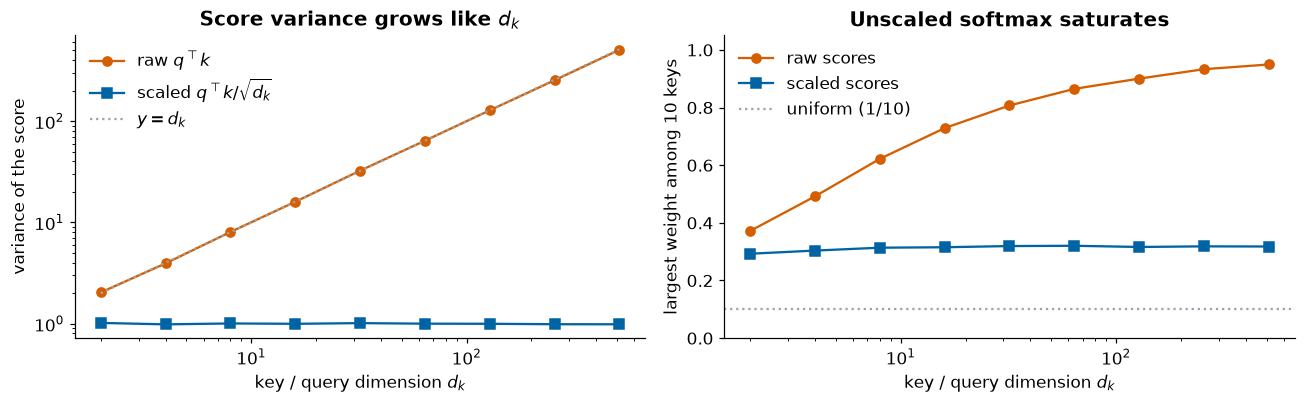

In [7]:
def sqrt_dk_stats(dks=(2, 4, 8, 16, 32, 64, 128, 256, 512), Lk=10, n=4000):
    rng_dk = np.random.default_rng(0)
    out = {k: [] for k in ["var_raw", "var_scaled", "max_raw", "max_scaled"]}
    for dk in dks:
        q = rng_dk.normal(size=(n, dk))
        k = rng_dk.normal(size=(n, Lk, dk))
        e = np.einsum("nd,nkd->nk", q, k)
        out["var_raw"].append(e.var()); out["var_scaled"].append((e / np.sqrt(dk)).var())
        out["max_raw"].append(softmax_rows(e).max(1).mean())
        out["max_scaled"].append(softmax_rows(e / np.sqrt(dk)).max(1).mean())
    return list(dks), out


dks, st = sqrt_dk_stats()
i64 = dks.index(64)
print(f"d_k = 64: raw score variance {st['var_raw'][i64]:.1f}, scaled {st['var_scaled'][i64]:.2f}; "
      f"largest of 10 softmax weights {st['max_raw'][i64]:.2f} unscaled vs {st['max_scaled'][i64]:.2f} scaled")

fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
axs[0].loglog(dks, st["var_raw"], "o-", color=COL_B, label="raw $q^\\top k$")
axs[0].loglog(dks, st["var_scaled"], "s-", color=COL_A, label="scaled $q^\\top k/\\sqrt{d_k}$")
axs[0].loglog(dks, dks, ":", color="#9AA5B1", label="$y = d_k$")
axs[0].set(xlabel="key / query dimension $d_k$", ylabel="variance of the score", title="Score variance grows like $d_k$")
axs[0].legend()
axs[1].semilogx(dks, st["max_raw"], "o-", color=COL_B, label="raw scores")
axs[1].semilogx(dks, st["max_scaled"], "s-", color=COL_A, label="scaled scores")
axs[1].axhline(0.1, color="#9AA5B1", ls=":", label="uniform (1/10)")
axs[1].set(ylim=(0, 1.05), xlabel="key / query dimension $d_k$", ylabel="largest weight among 10 keys",
           title="Unscaled softmax saturates")
axs[1].legend()
plt.tight_layout(); plt.show()

### 4.3 Multi-head self-attention
In **self**-attention, queries, keys and values all come from the same tokens $\mathbf X \in \mathbb R^{L\times d_{\text{model}}}$. With $H$ heads, head $i$ uses its own slice of the projections ($d_k = d_v = d_{\text{model}}/H$); the head outputs are concatenated and mixed by $\mathbf W_O \in \mathbb R^{H d_v \times d_{\text{model}}}$.

In [8]:
def multi_head(X, WQ, WK, WV, WO, H):
    """Multi-head self-attention. X: L x d_model; WQ, WK, WV, WO: d_model x d_model. Returns (L x d_model, H x L x L)."""
    L, d = X.shape
    assert d % H == 0 and all(W.shape == (d, d) for W in (WQ, WK, WV, WO))
    dk = d // H
    Q, K, V = X @ WQ, X @ WK, X @ WV                   # each L x d_model
    heads, As = [], []
    for i in range(H):
        sl = slice(i * dk, (i + 1) * dk)             # head i owns columns i*dk ... (i+1)*dk - 1
        O_i, A_i = attention(Q[:, sl], K[:, sl], V[:, sl])
        heads.append(O_i); As.append(A_i)
    concat = np.concatenate(heads, axis=1)            # L x (H d_v) = L x d_model
    out = concat @ WO
    assert concat.shape == (L, H * dk) and out.shape == (L, d)
    return out, np.stack(As)


rng_np = np.random.default_rng(1)
L_demo, d_demo, H_demo = 6, 8, 2
Xd = rng_np.normal(size=(L_demo, d_demo))
Ws = [rng_np.normal(size=(d_demo, d_demo)) / np.sqrt(d_demo) for _ in range(4)]
out, As = multi_head(Xd, *Ws, H=H_demo)
print(f"X {Xd.shape} -> output {out.shape}; attention weights {As.shape} (heads x queries x keys); "
      f"rows sum to 1: {np.allclose(As.sum(-1), 1)}")

X (6, 8) -> output (6, 8); attention weights (2, 6, 6) (heads x queries x keys); rows sum to 1: True


### 4.4 Permutation equivariance, checked numerically
Shuffle the rows of $\mathbf X$ with a permutation matrix $\mathbf\Pi$: self-attention returns the **same rows, shuffled the same way**, $f(\mathbf\Pi\mathbf X) = \mathbf\Pi f(\mathbf X)$. After mean pooling over positions the result is **invariant** — "A then B" and "B then A" look identical. Adding positional encodings to $\mathbf X$ breaks the symmetry.

In [9]:
def sinusoidal(Lp, d):
    pos = np.arange(Lp)[:, None]
    i = np.arange(0, d, 2)[None]
    P = np.zeros((Lp, d))
    P[:, 0::2] = np.sin(pos / 10000 ** (i / d))
    P[:, 1::2] = np.cos(pos / 10000 ** (i / d))
    return P


perm = rng_np.permutation(L_demo)
Pi = np.eye(L_demo)[perm]                               # Pi @ X reorders the rows
f = lambda Z: multi_head(Z, *Ws, H=H_demo)[0]
print("max |f(Pi X) - Pi f(X)|             =", f"{np.abs(f(Pi @ Xd) - Pi @ f(Xd)).max():.1e}  (equivariant)")
print("max |mean f(Pi X) - mean f(X)|      =", f"{np.abs(f(Pi @ Xd).mean(0) - f(Xd).mean(0)).max():.1e}  (pooled: invariant)")
Pd = sinusoidal(L_demo, d_demo)
g = lambda Z: f(Z + Pd)                                 # positions are added *after* the shuffle
print("with positional encodings, max diff =", f"{np.abs(g(Pi @ Xd) - Pi @ g(Xd)).max():.2f}  (symmetry broken)")

max |f(Pi X) - Pi f(X)|             = 2.2e-16  (equivariant)
max |mean f(Pi X) - mean f(X)|      = 1.7e-16  (pooled: invariant)
with positional encodings, max diff = 1.20  (symmetry broken)


### 4.5 Sinusoidal positional encodings
$p_{t,2i} = \sin(t/10000^{2i/d_{\text{model}}})$, $p_{t,2i+1} = \cos(t/10000^{2i/d_{\text{model}}})$: low dimensions oscillate fast, high dimensions slowly, so every position gets a unique, smoothly varying code.

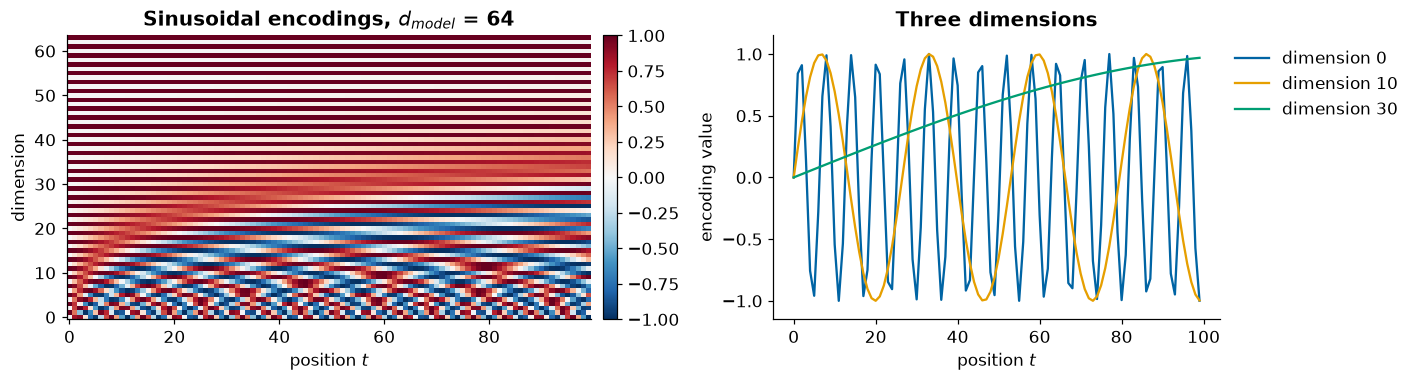

dot product p_t . p_s (d = 64): same position 32.0, 1 apart 30.9, 10 apart 21.1, 40 apart 15.4  -> depends on the offset


In [10]:
P100 = sinusoidal(100, 64)
fig, axs = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw=dict(width_ratios=[1.25, 1]))
im = axs[0].imshow(P100.T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1, origin="lower")
axs[0].set(xlabel="position $t$", ylabel="dimension", title="Sinusoidal encodings, $d_{model}$ = 64")
fig.colorbar(im, ax=axs[0], fraction=0.04, pad=0.02)
for j, c in zip([0, 10, 30], PALETTE[:3]):
    axs[1].plot(P100[:, j], color=c, label=f"dimension {j}")
axs[1].set(xlabel="position $t$", ylabel="encoding value", ylim=(-1.15, 1.15), title="Three dimensions")
axs[1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()
sim = P100 @ P100.T
print(f"dot product p_t . p_s (d = 64): same position {sim[50, 50]:.1f}, 1 apart {sim[50, 51]:.1f}, "
      f"10 apart {sim[50, 60]:.1f}, 40 apart {sim[50, 90]:.1f}  -> depends on the offset")

## 5. Model, part 2: a tiny Transformer in PyTorch

Same models as the lecture:
- **Embedding:** width-19 convolution (32 filters, as in L11) + ReLU + max pool 4 → $L = 50$ tokens of 4 bp, $d_{\text{model}} = 32$. `SeqConv` is a 1D convolution with "same" (zero) padding written as a product over sliding windows — mathematically `nn.Conv1d(4, 32, 19, padding=9)`, but faster on CPU for these shapes.
- **Add sinusoidal positional encodings** (optional: `pe=False`).
- **2 pre-LN encoder blocks**: $\mathbf X \leftarrow \mathbf X + \mathrm{MHA}(\mathrm{LN}(\mathbf X))$, $\mathbf X \leftarrow \mathbf X + \mathrm{FFN}(\mathrm{LN}(\mathbf X))$; $H = 2$ heads, FFN width 64.
- **Mean-pool** the tokens → LayerNorm → linear → logit; binary cross-entropy (L05).
- **Baseline: pooled CNN** (L11): same convolution → global max pool → linear.

In [11]:
class SeqConv(nn.Module):
    """1D convolution ('same' zero padding) as a product over sliding windows."""
    def __init__(s, cin, cout, k):
        super().__init__()
        s.k = k
        s.weight = nn.Parameter(torch.randn(cout, cin, k) / math.sqrt(cin * k))
        s.bias = nn.Parameter(torch.zeros(cout))

    def forward(s, x):                                         # x: n x c_in x L
        P = nn.functional.pad(x, (s.k // 2, s.k // 2)).unfold(2, s.k, 1)   # n x c_in x L x k
        return torch.einsum("bclk,ock->bol", P, s.weight) + s.bias[:, None]


class MHA(nn.Module):
    def __init__(s, d, h):
        super().__init__()
        s.h, s.dk = h, d // h
        s.WQ, s.WK, s.WV, s.WO = (nn.Linear(d, d, bias=False) for _ in range(4))

    def forward(s, X):                                         # X: n x L x d_model
        B, T, d = X.shape
        sp = lambda Z: Z.view(B, T, s.h, s.dk).transpose(1, 2)    # -> n x H x L x d_k
        Q, K, V = sp(s.WQ(X)), sp(s.WK(X)), sp(s.WV(X))
        A = torch.softmax(Q @ K.transpose(-1, -2) / math.sqrt(s.dk), -1)   # n x H x L x L
        s.A = A.detach()                                       # keep the last attention weights for plotting
        return s.WO((A @ V).transpose(1, 2).reshape(B, T, d))


class Block(nn.Module):
    def __init__(s, d, h, dff):
        super().__init__()
        s.n1, s.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        s.att = MHA(d, h)
        s.ff = nn.Sequential(nn.Linear(d, dff), nn.ReLU(), nn.Linear(dff, d))

    def forward(s, X):  # pre-LN
        X = X + s.att(s.n1(X))
        return X + s.ff(s.n2(X))


class TinyTransformer(nn.Module):
    def __init__(s, d=32, h=2, D=2, pe=True):
        super().__init__()
        s.embed = nn.Sequential(SeqConv(4, d, CONV_W), nn.ReLU(), nn.MaxPool1d(POOL))
        s.pe = pe
        s.register_buffer("P", torch.tensor(sinusoidal(SEQ_L // POOL, d), dtype=torch.float32))
        s.blocks = nn.ModuleList([Block(d, h, 2 * d) for _ in range(D)])
        s.norm = nn.LayerNorm(d)
        s.out = nn.Linear(d, 1)

    def tokens(s, x):                                          # n x 4 x 200 -> n x 50 x d_model
        X = s.embed(x).transpose(1, 2)
        return X + s.P if s.pe else X

    def head(s, X):                                            # encoder blocks + mean pool + linear
        for b in s.blocks:
            X = b(X)
        return s.out(s.norm(X).mean(1)).squeeze(-1)

    def forward(s, x):
        return s.head(s.tokens(x))


class PooledCNN(nn.Module):
    def __init__(s, d=32):
        super().__init__()
        s.net = nn.Sequential(SeqConv(4, d, CONV_W), nn.ReLU(), nn.AdaptiveMaxPool1d(1), nn.Flatten(), nn.Linear(d, 1))

    def forward(s, x):
        return s.net(x).squeeze(-1)


n_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"pooled CNN: {n_params(PooledCNN()):,} parameters;  tiny Transformer: {n_params(TinyTransformer()):,} parameters")
with torch.no_grad():
    print("shapes: input", tuple(X_te[:8].shape), "-> tokens", tuple(TinyTransformer().tokens(X_te[:8]).shape),
          "-> logits", tuple(TinyTransformer()(X_te[:8]).shape))

pooled CNN: 2,497 parameters;  tiny Transformer: 19,393 parameters
shapes: input (8, 4, 200) -> tokens (8, 50, 32) -> logits (8,)


**Check: the PyTorch attention layer equals our NumPy `multi_head`.** `nn.Linear` computes $\mathbf X\mathbf W^\top$, so the NumPy projection matrices are the transposed weights. And `SeqConv` equals `nn.Conv1d` with padding 9.

In [12]:
torch.manual_seed(1)
mha = MHA(32, 2)
Xt = torch.randn(1, 50, 32)
with torch.no_grad():
    y_torch = mha(Xt)[0].numpy()
y_np, A_np = multi_head(Xt[0].double().numpy(), *[lin.weight.detach().double().numpy().T for lin in
                                                   (mha.WQ, mha.WK, mha.WV, mha.WO)], H=2)
print(f"max |PyTorch - NumPy| output: {np.abs(y_torch - y_np).max():.1e}, weights: {np.abs(mha.A[0].numpy() - A_np).max():.1e}")
sc = SeqConv(4, 32, CONV_W)
ref = nn.Conv1d(4, 32, CONV_W, padding=CONV_W // 2)
with torch.no_grad():
    ref.weight.copy_(sc.weight); ref.bias.copy_(sc.bias)
    print(f"max |SeqConv - Conv1d|: {(sc(X_te[:16]) - ref(X_te[:16])).abs().max():.1e}")

max |PyTorch - NumPy| output: 4.2e-08, weights: 1.2e-08
max |SeqConv - Conv1d|: 4.8e-07


## 6. Training
AdamW (η = 2 × 10⁻³, weight decay 10⁻²), batch 64, 10 epochs, `torch.manual_seed(0)` before each model — the lecture's settings. We record test accuracy after every epoch (there is no model selection, so this is a learning curve, not tuning on the test set).

In [13]:
def train(make, X=X_tr, y=yt_tr, Xv=X_te, yv=yt_te, epochs=EPOCHS, seed=0, verbose=True):
    torch.manual_seed(seed)
    m = make()
    opt = torch.optim.AdamW(m.parameters(), lr=2e-3, weight_decay=1e-2)
    lossf = nn.BCEWithLogitsLoss()
    hist, t0 = [], time.time()
    for ep in range(epochs):
        m.train()
        perm = torch.randperm(len(X))
        for i in range(0, len(perm), 64):
            b = perm[i:i + 64]
            opt.zero_grad()
            lossf(m(X[b]), y[b]).backward()
            opt.step()
        m.eval()
        with torch.no_grad():
            pred = (m(Xv) > 0).float()
        hist.append((pred == yv).float().mean().item())
    if verbose:
        print(f"  {n_params(m):,} params, test accuracy {hist[-1]:.3f}, {time.time() - t0:.0f} s")
    return m, np.array(hist), (pred == yv).numpy()


runs = {}
for name, make in [("cnn", PooledCNN), ("tf_nope", lambda: TinyTransformer(pe=False)), ("tf", TinyTransformer)]:
    print(name)
    runs[name] = train(make)

cnn


  2,497 params, test accuracy 0.494, 6 s
tf_nope


  19,393 params, test accuracy 0.545, 18 s
tf


  19,393 params, test accuracy 0.941, 21 s


## 7. Evaluation

model                         params test acc.
Pooled CNN                     2,497     0.494
Transformer, no positions     19,393     0.545
Transformer + positions       19,393     0.941

Transformer + positions, accuracy by distance between site starts:
    0- 49 bp: 89%  (n = 349)
   50- 99 bp: 97%  (n = 402)
  100-199 bp: 97%  (n = 249)


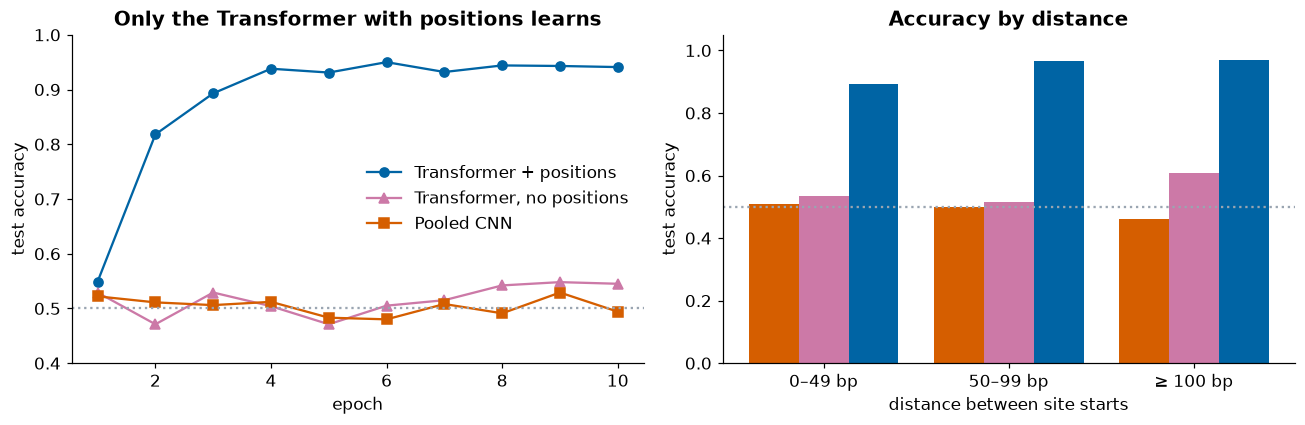

In [14]:
labels = {"cnn": "Pooled CNN", "tf_nope": "Transformer, no positions", "tf": "Transformer + positions"}
print(f"{'model':28s} {'params':>7s} {'test acc.':>9s}")
for k in ["cnn", "tf_nope", "tf"]:
    print(f"{labels[k]:28s} {n_params(runs[k][0]):7,d} {runs[k][1][-1]:9.3f}")

sep_te = np.abs(pos_te[:, 0] - pos_te[:, 1])       # distance between site starts
bins = [(0, 50), (50, 100), (100, 200)]
print("\nTransformer + positions, accuracy by distance between site starts:")
for lo, hi in bins:
    sel = (sep_te >= lo) & (sep_te < hi)
    print(f"  {lo:3d}-{hi - 1:3d} bp: {runs['tf'][2][sel].mean():.0%}  (n = {sel.sum()})")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
ep = np.arange(1, EPOCHS + 1)
for k, c, mk in [("tf", COL_A, "o"), ("tf_nope", PALETTE[3], "^"), ("cnn", COL_B, "s")]:
    axs[0].plot(ep, runs[k][1], marker=mk, color=c, label=labels[k])
axs[0].axhline(0.5, color="#9AA5B1", ls=":")
axs[0].set(ylim=(0.4, 1.0), xlabel="epoch", ylabel="test accuracy", title="Only the Transformer with positions learns")
axs[0].legend(loc="center right")
xb = np.arange(len(bins))
for j, (k, c) in enumerate([("cnn", COL_B), ("tf_nope", PALETTE[3]), ("tf", COL_A)]):
    accs = [runs[k][2][(sep_te >= lo) & (sep_te < hi)].mean() for lo, hi in bins]
    axs[1].bar(xb + (j - 1) * 0.27, accs, width=0.27, color=c, label=labels[k])
axs[1].axhline(0.5, color="#9AA5B1", ls=":")
axs[1].set_xticks(xb, ["0–49 bp", "50–99 bp", "≥ 100 bp"])
axs[1].set(ylim=(0, 1.05), xlabel="distance between site starts", ylabel="test accuracy", title="Accuracy by distance")
plt.tight_layout(); plt.show()

**Reading the table.**
- The **pooled CNN** detects both motifs perfectly well — useless here, because both are *always* present. Global max pooling keeps "is there a CTCF site?" but throws away *where*, so it is at chance.
- The **Transformer without positional encodings** is order-blind (Section 4.4): after the convolutional embedding, attention + mean pooling give the same output for any shuffling of the 50 tokens. It is only slightly above chance. The small margin comes from a **padding leak**: the 19-bp convolution uses zero ("same") padding, so the first and last few tokens see padding and are embedded differently from interior tokens. A motif token that touches an edge therefore "knows" it is at the start or the end of the sequence — and a CTCF site at the very start is almost always upstream of FOXA1. Position leaks in only at the edges, so only a few sequences benefit (checked below).
- The **Transformer with positions** solves the task. Distant pairs are the *easy* case; close pairs (< 50 bp) are harder because after pooling to 4-bp tokens the two sites can share or neighbour tokens, and the token-level positions blur their order.

**Numbers vs the slides.** The deck reports 0.494 / 0.571 / 0.930 (pooled CNN / no positions / with positions), accuracy by distance 85% / 97% / 98%, and heads L1H1 75% on CTCF, L2H1 79% on FOXA1. This notebook uses the identical data, seeds and code (running the lecture file's own training function on this machine gives exactly the values printed above: 0.494 / 0.545 / 0.941, 89% / 97% / 97%, L1H1 78% and L2H1 78%), but the Transformer runs land on different numbers: floating-point differences between machines / PyTorch versions change the training trajectory. The pooled CNN reproduces exactly (0.494). Changing only the training seed (1, 2) gives no-position accuracies 0.47 and 0.57 and with-position accuracies 0.94 and 0.94, so the no-position result is "chance plus a small padding leak", not a precise number; the conclusions are unchanged.

Not a fair size comparison (2.5k vs 19k parameters): the point is what each architecture *can represent*. L11's CNN + BiLSTM solved the spacing-limited version of this task; its numbers are not directly comparable.

In [15]:
m_nope = runs["tf_nope"][0]
with torch.no_grad():
    Xtok = m_nope.tokens(X_te[:200])
    shuffled = Xtok[:, torch.randperm(Xtok.shape[1])]           # shuffle the 50 tokens of every sequence
    print(f"no-position Transformer: max |logit(shuffled tokens) - logit(tokens)| = "
          f"{(m_nope.head(shuffled) - m_nope.head(Xtok)).abs().max():.1e}  (order-blind after the embedding)")
edge = CONV_W // 2 + POOL                                           # sites this close to an end touch the zero padding
near = (np.minimum(pos_te.min(1), SEQ_L - (pos_te + [WA, WB]).max(1)) < edge)
corr_nope = runs["tf_nope"][2]
print(f"padding leak: no-position accuracy {corr_nope[near].mean():.0%} when a site lies within {edge} bp of an end "
      f"(n = {near.sum()}) vs {corr_nope[~near].mean():.0%} otherwise (n = {(~near).sum()})")

no-position Transformer: max |logit(shuffled tokens) - logit(tokens)| = 6.3e-07  (order-blind after the embedding)
padding leak: no-position accuracy 66% when a site lies within 13 bp of an end (n = 279) vs 50% otherwise (n = 721)


## 8. Visualization: which positions does each head read?
We run the trained Transformer on 500 test sequences and, for every layer and head, measure how much attention lands on the token holding each site's centre and its two neighbours (3 of 50 tokens, so 6% if attention were uniform). The heads that find each motif are selected programmatically (they can differ between runs).

In [16]:
def head_stats(m, n=500):
    """Mean attention mass on the CTCF (A) and FOXA1 (B) tokens, per (layer, head). Also returns the maps."""
    with torch.no_grad():
        m(X_te[:n])
    T = SEQ_L // POOL
    ta = np.clip((pos_te[:n, 0] + WA // 2) // POOL, 0, T - 1)    # token holding the site's centre
    tb = np.clip((pos_te[:n, 1] + WB // 2) // POOL, 0, T - 1)
    idx = np.arange(n)
    stats, maps = [], []
    for li, blk in enumerate(m.blocks):
        A_ = blk.att.A.numpy()
        for hh in range(A_.shape[1]):
            Ah = A_[:, hh]
            toA = sum(Ah[idx, :, np.clip(ta + o, 0, T - 1)] for o in (-1, 0, 1)).mean()
            toB = sum(Ah[idx, :, np.clip(tb + o, 0, T - 1)] for o in (-1, 0, 1)).mean()
            stats.append((li + 1, hh + 1, float(toA), float(toB)))
            maps.append(Ah)
    return stats, maps, 3 / T


stats, maps, uniform = head_stats(runs["tf"][0])
for li, hh, a, b in stats:
    print(f"layer {li} head {hh}: {a:.0%} of attention on {nameA} tokens, {b:.0%} on {nameB} tokens")
hA = int(np.argmax([s_[2] for s_ in stats]))
hB = int(np.argmax([s_[3] for s_ in stats]))
print(f"uniform: {uniform:.0%};  A-finding head = L{stats[hA][0]}H{stats[hA][1]} ({stats[hA][2]:.0%}), "
      f"B-finding head = L{stats[hB][0]}H{stats[hB][1]} ({stats[hB][3]:.0%})")

layer 1 head 1: 78% of attention on CTCF tokens, 0% on FOXA1 tokens
layer 1 head 2: 31% of attention on CTCF tokens, 2% on FOXA1 tokens
layer 2 head 1: 1% of attention on CTCF tokens, 78% on FOXA1 tokens
layer 2 head 2: 3% of attention on CTCF tokens, 20% on FOXA1 tokens
uniform: 6%;  A-finding head = L1H1 (78%), B-finding head = L2H1 (78%)


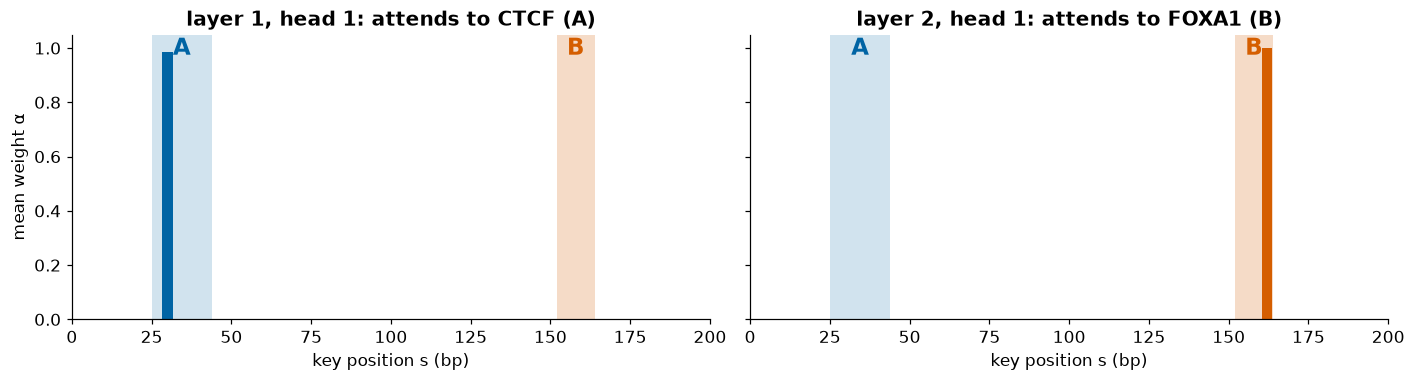

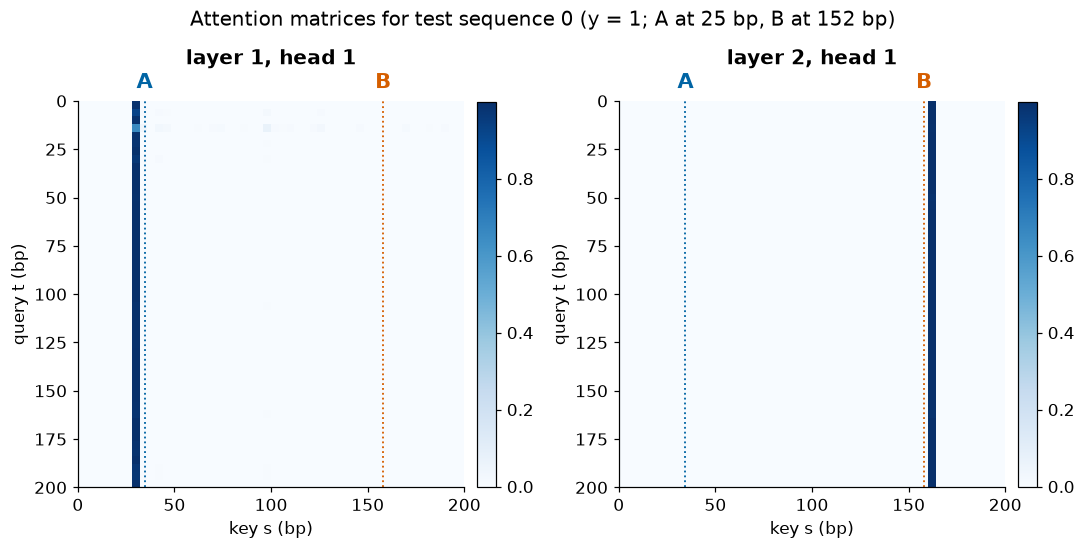

In [17]:
ex = [i for i in range(500) if y_te[i] == 1 and abs(pos_te[i, 0] - pos_te[i, 1]) > 70][0]   # a positive, sites > 70 bp apart
pa, pb = pos_te[ex]
T = SEQ_L // POOL
xs = np.arange(T) * POOL + POOL / 2
fig, axs = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, h, which, col in zip(axs, [hA, hB], [f"{nameA} (A)", f"{nameB} (B)"], [COL_A, COL_B]):
    prof = maps[h][ex].mean(0)                                 # attention received by each key, averaged over queries
    ax.axvspan(pa, pa + WA, color=COL_A, alpha=0.18, lw=0)
    ax.axvspan(pb, pb + WB, color=COL_B, alpha=0.22, lw=0)
    ax.bar(xs, prof, width=POOL * 0.85, color=col)
    for p0, w, lab, c in [(pa, WA, "A", COL_A), (pb, WB, "B", COL_B)]:
        ax.text(p0 + w / 2, 0.93, lab, ha="center", fontsize=15, color=c, weight="bold", transform=ax.get_xaxis_transform())
    ax.set(title=f"layer {stats[h][0]}, head {stats[h][1]}: attends to {which}", xlabel="key position s (bp)", xlim=(0, SEQ_L))
axs[0].set_ylabel("mean weight α")
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ext = [0, T * POOL, T * POOL, 0]
for ax, h in zip(axs, [hA, hB]):
    Mh = maps[h][ex]
    im = ax.imshow(Mh, cmap="Blues", vmin=0, vmax=Mh.max(), extent=ext, interpolation="nearest")
    for p0, w, lab, c in [(pa, WA, "A", COL_A), (pb, WB, "B", COL_B)]:
        ax.axvline(p0 + w / 2, color=c, lw=1.2, ls=":")
        ax.text(p0 + w / 2, -4, lab, ha="center", va="bottom", fontsize=14, color=c, weight="bold")
    ax.set_title(f"layer {stats[h][0]}, head {stats[h][1]}", pad=24)
    ax.set(xlabel="key s (bp)", ylabel="query t (bp)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
fig.suptitle(f"Attention matrices for test sequence {ex} (y = 1; A at {pa} bp, B at {pb} bp)")
plt.tight_layout(); plt.show()

Row $t$ is a query, column $s$ a key; each row sums to 1. The **vertical stripes** mean that *every* query reads from the same key — the motif site — however far away it is. A width-19 convolution could not link sites 100 bp apart in one layer. The positional encodings travel with the retrieved values, so after the two heads have gathered "CTCF is here" and "FOXA1 is here", the rest of the network can compare the two locations.

## 9. Biological interpretation

- **Convolutions find words; attention relates them.** The convolutional embedding plays the role of a PWM scanner (L03, L11); attention lets each position look up its partner anywhere in the sequence, in one layer. This is the design of Enformer (Avsec et al., 2021): convolutions and pooling shrink ~200 kb to 1,536 tokens, then Transformer blocks connect enhancers to promoters up to ~100 kb away.
- **Position must be supplied.** Self-attention sees a *set* of tokens. For regulatory grammar (order, orientation, spacing) the model needs positional information — sinusoidal, learned, or relative/rotary encodings. Accidental position signals such as zero padding are real and can fool you when you interpret a model.
- **Attention maps are clues, not explanations.** Here the heads line up with the planted motifs because we built the data. On real genomes, attention weights show where information is read from, not why the prediction is made; validate with perturbations (in silico mutagenesis) and experiments.
- The rule here is a toy: real TF cooperativity involves flexible spacing, orientation, chromatin context and cell type.

## Try it yourself

1. **Remove the positional encodings.** What happens to accuracy? (Already run above as `tf_nope`; try also `train(lambda: TinyTransformer(pe=False, D=4))` — do more layers help without positions?)
2. **Add L11's spacing rule (within 10–49 bp). Still learnable?** Regenerate the data with `make_grammar(N, rng, gap=(10, 50))` for both train and test (cell below), then retrain the pooled CNN and both Transformers.
3. **Use one head instead of two. Do the motif-finding heads merge?** Train `TinyTransformer(h=1)` and look at `head_stats(...)`: does one head per layer still find one motif each?
4. **Learned positional encodings:** in `TinyTransformer.__init__`, replace the `register_buffer(...)` line by `s.P = nn.Parameter(0.02 * torch.randn(SEQ_L // POOL, d))` (1,600 extra parameters). Does it reach the same accuracy in 10 epochs? Plot `P` after training: does it look sinusoidal?
5. **(CS284A) Close the padding leak.** In `SeqConv.forward`, use circular padding (`nn.functional.pad(x, (s.k // 2, s.k // 2), mode="circular")`) and retrain the no-position Transformer. Prove that the model is then exactly invariant to *cyclic shifts* of the input by multiples of 4 bp. Does its accuracy drop to chance, including for sites near the ends? Does the model with positional encodings still work?

In [18]:
# Try 2 (edit and run): L11's spacing window. Uncomment to run (~1 min for three models).
# rng2 = seed_everything(0)
# S_tr2, y_tr2, pos_tr2 = make_grammar(N_TRAIN, rng2, gap=(10, 50))
# S_te2, y_te2, pos_te2 = make_grammar(N_TEST, rng2, gap=(10, 50))
# X_tr2, X_te2 = (torch.tensor(onehot(s_)).transpose(1, 2) for s_ in (S_tr2, S_te2))
# for name, make in [("cnn", PooledCNN), ("tf_nope", lambda: TinyTransformer(pe=False)), ("tf", TinyTransformer)]:
#     print(name); train(make, X=X_tr2, y=torch.tensor(y_tr2).float(), Xv=X_te2, yv=torch.tensor(y_te2).float())

# Try 3: one head per layer
# m1, h1, _ = train(lambda: TinyTransformer(h=1))
# for li, hh, a, b in head_stats(m1)[0]: print(f"layer {li} head {hh}: {a:.0%} on A, {b:.0%} on B")